In [27]:
import sys
import pandas as pd
sys.path.append("..")

from load_data import load_all, load_year

df = load_all()               # all four years stacked
print(df.groupby("year").size())
df_2024 = load_year("2024")   # just one year

year
2021     53873
2022     45230
2023     49844
2024     68206
2025    128799
dtype: int64


In [28]:
# Timely vs. late responses for each year

print("")
counts = pd.crosstab(df["Timely response?"], df["year"])
pct = (counts / counts.sum() * 100).round(2)

timely_table = counts.astype(str) + " (" + pct.map(lambda x: f"{x:.2f}%") + ")"
timely_table

year,2021,2022,2023,2024,2025
Timely response?,,,,,
No,1690 (3.14%),1351 (2.99%),1155 (2.32%),1351 (1.98%),3468 (2.69%)
Yes,52183 (96.86%),43879 (97.01%),48689 (97.68%),66855 (98.02%),125331 (97.31%)


In [29]:
# Late-response rate by company, one column per year
by_company = (
    df.groupby(["Company", "year"])["late"]
      .agg(late_rate="mean", complaints="size")
      .reset_index()
)

rate = by_company.pivot(index="Company", columns="year", values="late_rate")
n = by_company.pivot(index="Company", columns="year", values="complaints")

# Keep companies with at least 100 complaints in every year
enough = (n >= 100).all(axis=1)
late_by_company = (rate[enough] * 100).round(1).sort_values("2024", ascending=False)

print(f"{enough.sum()} companies with 100+ complaints in every year")
late_by_company.head(15)

46 companies with 100+ complaints in every year


year,2021,2022,2023,2024,2025
Company,,,,,
"CCS Financial Services, Inc.",8.3,10.0,5.8,20.1,41.2
"United Collection Bureau, Inc.",0.0,1.0,2.9,2.8,1.4
"Ability Recovery Services, LLC",0.0,3.3,1.4,2.4,2.0
"BANK OF AMERICA, NATIONAL ASSOCIATION",19.0,5.5,3.8,1.8,0.4
"Portfolio Recovery Associates, LLC",0.0,0.0,0.0,0.7,3.9
CREDIT ACCEPTANCE CORPORATION,0.0,0.6,1.5,0.4,0.3
"Westlake Services, LLC",0.0,0.0,0.0,0.4,0.0
TRANSWORLD SYSTEMS INC,0.0,0.0,0.1,0.3,0.1
"Aldous & Associates, PLLC",0.0,0.0,0.0,0.2,0.0


In [30]:
# How concentrated are late responses? Share coming from the top 5 companies each year
late_only = df[df["late"] == 1]

rows = []
for year, g in late_only.groupby("year"):
    counts = g["Company"].value_counts()
    rows.append({
        "year": year,
        "late responses": len(g),
        "companies with any late": counts.size,
        "top 5 share (%)": round(counts.head(5).sum() / len(g) * 100, 1),
        "top company": counts.index[0],
        "top company late count": counts.iloc[0],
    })

concentration = pd.DataFrame(rows).set_index("year")
concentration

,late responses,companies with any late,top 5 share (%),top company,top company late count
year,,,,,
2021,1690,442,25.7,"Capital Accounts, LLC",132
2022,1351,405,22.1,HCFS Healthcare Financial Services of TeamHealth,83
2023,1155,390,16.9,"CCS Financial Services, Inc.",60
2024,1351,420,29.3,"CCS Financial Services, Inc.",276
2025,3468,674,38.2,"CCS Financial Services, Inc.",782


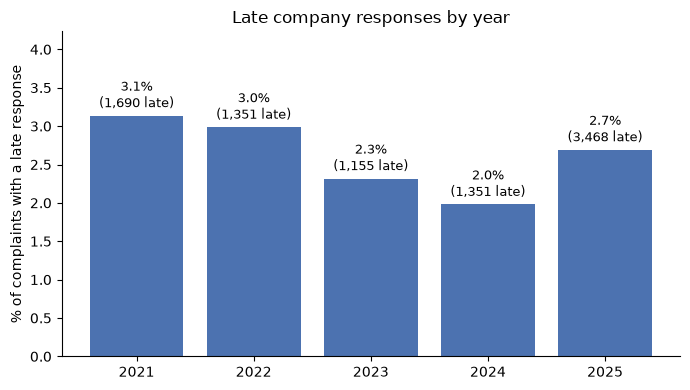

In [31]:
import matplotlib.pyplot as plt

yearly = df.groupby("year")["late"].agg(late_rate="mean", late_count="sum", complaints="size")
yearly["late_rate"] *= 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(yearly.index, yearly["late_rate"], color="#4C72B0")
ax.bar_label(
    bars,
    labels=[f"{r:.1f}%\n({c:,} late)" for r, c in zip(yearly["late_rate"], yearly["late_count"])],
    padding=3, fontsize=9,
)
ax.set_ylabel("% of complaints with a late response")
ax.set_title("Late company responses by year")
ax.set_ylim(0, yearly["late_rate"].max() * 1.35)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Top 6: 2.6% of complaints, 37.1% of late responses


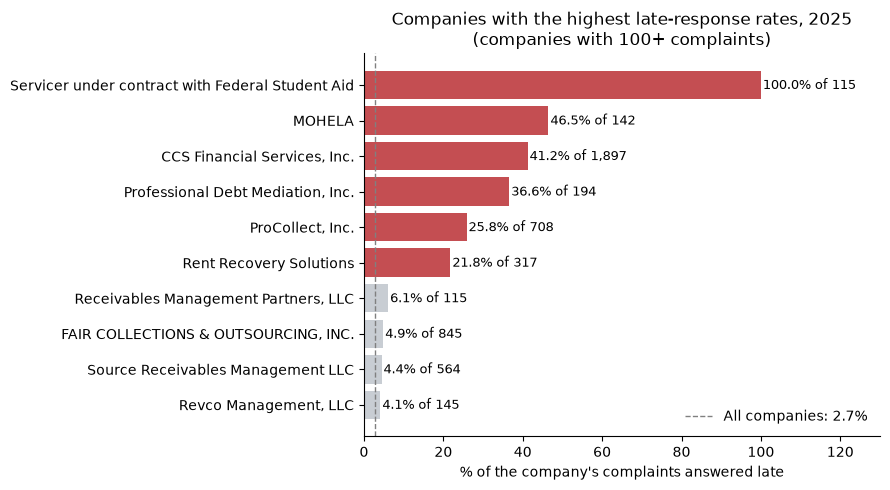

In [32]:
latest = df["year"].max()
d = df[df["year"] == latest]

top = (d.groupby("Company")["late"]
        .agg(late_rate="mean", complaints="size", late_count="sum")
        .query("complaints >= 100")
        .sort_values("late_rate", ascending=False)
        .head(10))
top["late_rate"] *= 100
overall = d["late"].mean() * 100

# Numbers for the line under the chart
top6 = top.head(6)
print(f"Top 6: {top6['complaints'].sum() / len(d):.1%} of complaints, "
      f"{top6['late_count'].sum() / d['late'].sum():.1%} of late responses")

colors = ["#C44E52"] * 6 + ["#C8CDD3"] * 4   # top 6 red, the rest gray

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index[::-1], top["late_rate"][::-1], color=colors[::-1])
ax.axvline(overall, color="gray", linestyle="--", linewidth=1,
           label=f"All companies: {overall:.1f}%")
for i, (rate, n) in enumerate(zip(top["late_rate"][::-1], top["complaints"][::-1])):
    ax.text(rate + 0.5, i, f"{rate:.1f}% of {n:,}", va="center", fontsize=9)
ax.set_xlabel("% of the company's complaints answered late")
ax.set_title(f"Companies with the highest late-response rates, {latest}\n(companies with 100+ complaints)")
ax.set_xlim(0, top["late_rate"].max() * 1.3)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

# Features known when the complaint is filed.
# Leave out "Company response to consumer" and "Company public response":
# they're filled in after the company responds, so they give away the answer.
feature_sets = {
    "Company only":           ["Company"],
    "Everything but company": ["Sub-product", "Issue", "State", "Submitted via", "Tags"],
    "Everything":             ["Company", "Sub-product", "Issue", "State", "Submitted via", "Tags"],
}

results = []
for year, d in df.groupby("year"):
    X = d[feature_sets["Everything"]].fillna("Missing")
    y = d["late"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y)

    for name, cols in feature_sets.items():
        model = make_pipeline(
            OneHotEncoder(handle_unknown="ignore", min_frequency=20),
            LogisticRegression(max_iter=1000))
        model.fit(X_train[cols], y_train)
        p = model.predict_proba(X_test[cols])[:, 1]
        results.append({
            "year": year,
            "features": name,
            "AUC": round(roc_auc_score(y_test, p), 3),
            "AP": round(average_precision_score(y_test, p), 3),
            "late rate": round(y_test.mean(), 3),
        })

model_results = pd.DataFrame(results)
model_results.pivot(index="features", columns="year", values=["AUC", "AP"])

AUC                                 AP         \
year                     2021   2022   2023   2024   2025   2021   2022   
features                                                                  
Company only            0.889  0.858  0.863  0.920  0.948  0.286  0.147   
Everything              0.890  0.858  0.861  0.917  0.947  0.323  0.161   
Everything but company  0.641  0.643  0.668  0.728  0.685  0.060  0.054   

                                             
year                     2023   2024   2025  
features                                     
Company only            0.147  0.181  0.365  
Everything              0.159  0.198  0.407  
Everything but company  0.045  0.049  0.064

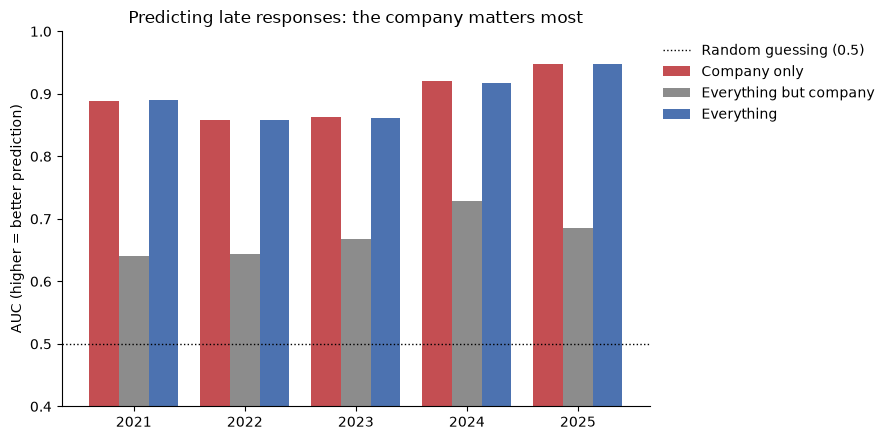

In [34]:
auc = model_results.pivot(index="year", columns="features", values="AUC")
auc = auc[["Company only", "Everything but company", "Everything"]]

ax = auc.plot(kind="bar", figsize=(9, 4.5), width=0.8,
              color=["#C44E52", "#8C8C8C", "#4C72B0"])
ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="Random guessing (0.5)")
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("AUC (higher = better prediction)")
ax.set_xlabel("")
ax.set_title("Predicting late responses: the company matters most")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
ax.tick_params(axis="x", rotation=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

year,2021,2022,2023,2024,2025
Sub-product,,,,,
Federal student loan debt,1.8,1.9,3.5,3.2,15.9
Payday loan debt,5.6,4.8,5.6,5.8,6.5
Medical debt,5.9,5.8,5.1,5.6,6.1
Private student loan debt,2.6,2.8,1.8,3.0,4.6
Rental debt,NaN,NaN,1.8,NaN,4.4
Mortgage debt,2.3,2.5,2.5,1.9,2.9
Other debt,2.8,2.9,2.6,2.0,2.6
Auto debt,2.5,2.1,1.9,2.0,2.4
Credit card debt,1.9,1.4,0.7,0.7,1.3


year,2021,2022,2023,2024,2025
Issue,,,,,
Threatened to contact someone or share information improperly,5.0,3.4,3.5,3.7,4.0
Took or threatened to take negative or legal action,4.3,3.2,2.8,3.2,3.8
False statements or representation,4.2,3.6,2.8,2.9,3.6
Communication tactics,3.7,2.6,2.2,2.1,3.4
Attempts to collect debt not owed,2.7,2.8,2.1,2.0,2.7
Electronic communications,NaN,NaN,1.3,2.1,2.6
Written notification about debt,3.3,3.2,2.3,1.4,1.9


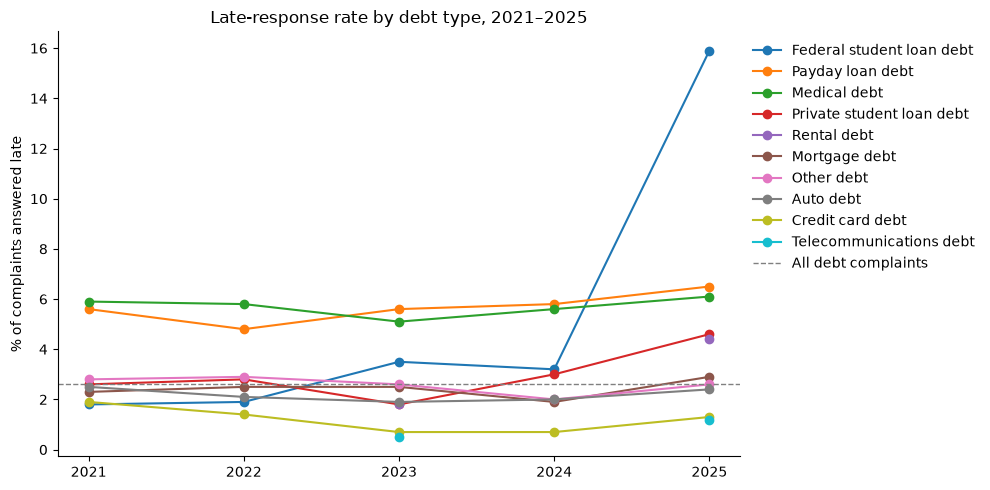

In [35]:
import matplotlib.pyplot as plt

def late_table(col, min_complaints=100):
    """Late-response rate (%) for each value of `col`, one column per year."""
    g = df.groupby([col, "year"])["late"].agg(late_rate="mean", complaints="size").reset_index()
    rate = g.pivot(index=col, columns="year", values="late_rate") * 100
    n = g.pivot(index=col, columns="year", values="complaints")
    rate = rate.where(n >= min_complaints)          # hide rates based on too few complaints
    return rate.round(1).sort_values(rate.columns[-1], ascending=False)

late_by_subproduct = late_table("Sub-product")
late_by_issue = late_table("Issue")

display(late_by_subproduct)
display(late_by_issue)

# Chart: late rate by debt type over time
fig, ax = plt.subplots(figsize=(10, 5))
for sub, row in late_by_subproduct.iterrows():
    ax.plot(row.index, row.values, marker="o", label=sub)
ax.axhline(df["late"].mean() * 100, color="gray", linestyle="--", linewidth=1,
           label="All debt complaints")
ax.set_ylabel("% of complaints answered late")
ax.set_title("Late-response rate by debt type, 2021–2025")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

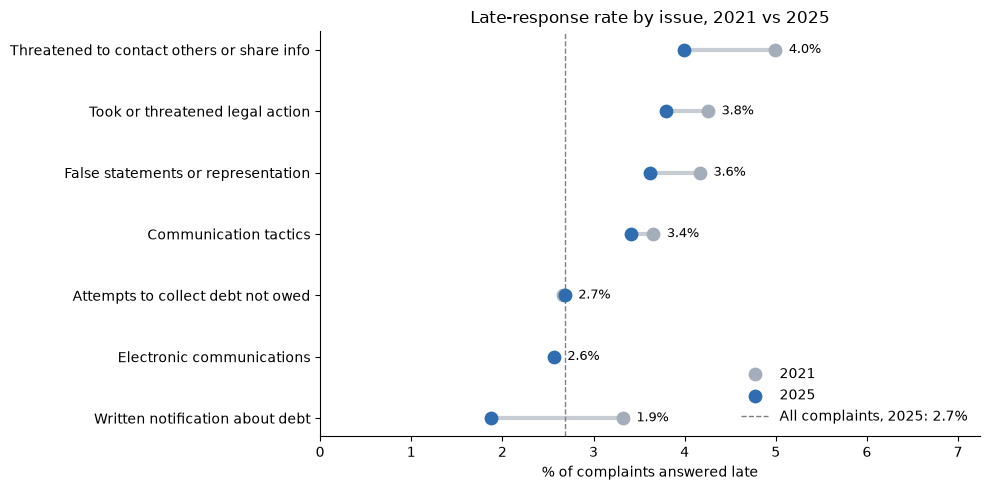

In [36]:
import matplotlib.pyplot as plt

first, latest = df["year"].min(), df["year"].max()

issue = (df[df["year"].isin([first, latest])]
         .groupby(["Issue", "year"])["late"].agg(rate="mean", n="size").reset_index())
issue = issue[issue["n"] >= 100]
rate = issue.pivot(index="Issue", columns="year", values="rate") * 100
rate = rate.sort_values(latest)

# Shorter labels for the two longest issue names
short = {
    "Threatened to contact someone or share information improperly": "Threatened to contact others or share info",
    "Took or threatened to take negative or legal action": "Took or threatened legal action",
}
labels = [short.get(i, i) for i in rate.index]
overall = df.loc[df["year"] == latest, "late"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
for i, (iss, row) in enumerate(rate.iterrows()):
    if pd.notna(row[first]):
        ax.plot([row[first], row[latest]], [i, i], color="#C8CDD3", linewidth=3, zorder=1)
        ax.scatter(row[first], i, color="#A3AEBA", s=80, zorder=2, label=first if i == 0 else None)
    ax.scatter(row[latest], i, color="#2F6DB0", s=80, zorder=3, label=latest if i == 0 else None)
    right_edge = max(row[latest], row[first]) if pd.notna(row[first]) else row[latest]
    ax.text(right_edge + 0.15, i, f"{row[latest]:.1f}%", va="center", fontsize=9)

ax.axvline(overall, color="gray", linestyle="--", linewidth=1,
           label=f"All complaints, {latest}: {overall:.1f}%")
ax.set_yticks(range(len(rate)))
ax.set_yticklabels(labels)
ax.set_xlabel("% of complaints answered late")
ax.set_xlim(0, rate.max().max() * 1.45)
ax.set_title(f"Late-response rate by issue, {first} vs {latest}")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

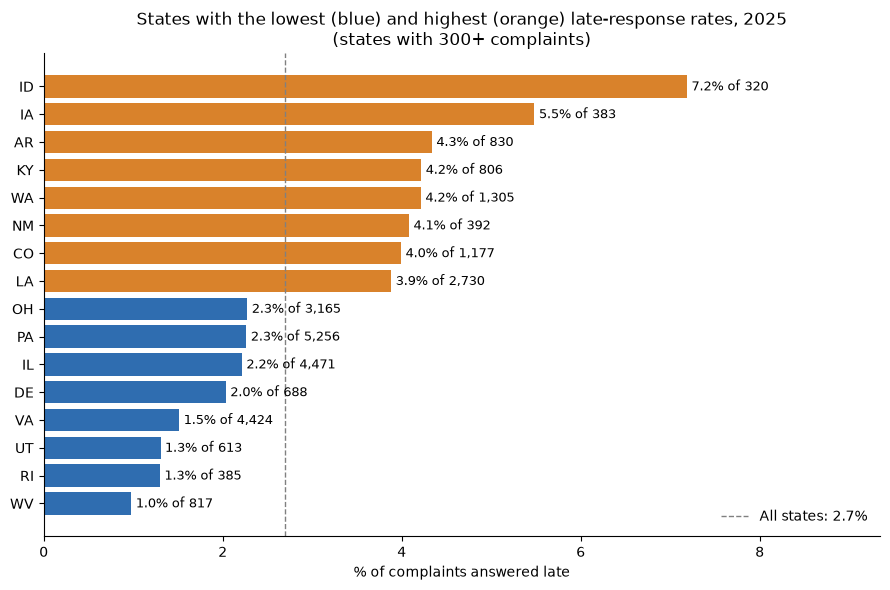

In [37]:
latest = df["year"].max()
d = df[df["year"] == latest]

st = d.groupby("State")["late"].agg(late_rate="mean", complaints="size").reset_index()
st = st[st["complaints"] >= 300]          # only states with enough complaints
st["late_rate"] *= 100
st = st.sort_values("late_rate")

show = pd.concat([st.head(8), st.tail(8)])  # 8 lowest and 8 highest
overall = d["late"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2F6DB0"] * 8 + ["#D9822B"] * 8
ax.barh(show["State"], show["late_rate"], color=colors)
ax.axvline(overall, color="gray", linestyle="--", linewidth=1,
           label=f"All states: {overall:.1f}%")
for i, (r, n) in enumerate(zip(show["late_rate"], show["complaints"])):
    ax.text(r + 0.05, i, f"{r:.1f}% of {n:,}", va="center", fontsize=9)
ax.set_xlabel("% of complaints answered late")
ax.set_title(f"States with the lowest (blue) and highest (orange) late-response rates, {latest}\n(states with 300+ complaints)")
ax.set_xlim(0, show["late_rate"].max() * 1.3)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

,factor,year,groups compared,lowest (%),highest (%),spread (pts)
0,Company,2021,94,0.0,100.0,100.0
1,Company,2022,85,0.0,37.0,37.0
2,Company,2023,94,0.0,15.7,15.7
3,Company,2024,77,0.0,20.1,20.1
4,Company,2025,136,0.0,100.0,100.0
5,Sub-product,2021,8,1.8,5.9,4.1
6,Sub-product,2022,8,1.4,5.8,4.4
7,Sub-product,2023,10,0.5,5.6,5.2
8,Sub-product,2024,8,0.7,5.8,5.2
9,Sub-product,2025,10,1.2,15.9,14.7


FileNotFoundError: [Errno 2] No such file or directory: 'late_rate_by_factor.png'

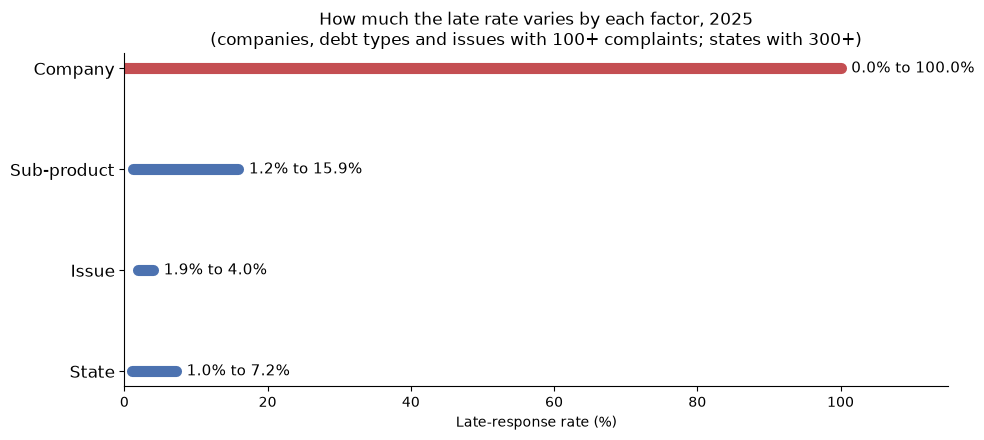

In [38]:
import matplotlib.pyplot as plt

def spread(col, min_complaints=100):
    """How much the late rate varies across the values of `col`, for each year."""
    rows = []
    for year, d in df.groupby("year"):
        g = d.groupby(col)["late"].agg(rate="mean", n="size")
        g = g[g["n"] >= min_complaints]           # only groups with enough complaints
        rows.append({
            "factor": col,
            "year": year,
            "groups compared": len(g),
            "lowest (%)": round(g["rate"].min() * 100, 1),
            "highest (%)": round(g["rate"].max() * 100, 1),
            "spread (pts)": round((g["rate"].max() - g["rate"].min()) * 100, 1),
        })
    return rows

factors = ["Company", "Sub-product", "Issue", "State"]
min_by_factor = {"Company": 100, "Sub-product": 100, "Issue": 100, "State": 300}

spread_table = pd.DataFrame([
    r for f in factors for r in spread(f, min_complaints=min_by_factor[f])
])
display(spread_table)

# Chart: the latest year
latest = df["year"].max()
s = spread_table[spread_table["year"] == latest].set_index("factor")

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (factor, row) in enumerate(s.iterrows()):
    color = "#C44E52" if factor == "Company" else "#4C72B0"
    ax.plot([row["lowest (%)"], row["highest (%)"]], [i, i],
            color=color, linewidth=8, solid_capstyle="round")
    ax.text(row["highest (%)"] + 1.5, i,
            f'{row["lowest (%)"]:.1f}% to {row["highest (%)"]:.1f}%',
            va="center", fontsize=11)

ax.set_yticks(range(len(s)))
ax.set_yticklabels(s.index, fontsize=12)
ax.invert_yaxis()
ax.set_xlim(0, 115)
ax.set_xlabel("Late-response rate (%)")
ax.set_title(f"How much the late rate varies by each factor, {latest}\n"
             "(companies, debt types and issues with 100+ complaints; states with 300+)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("late_rate_by_factor.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Flag the three nationwide credit bureaus
bureau_pattern = "EQUIFAX|TRANSUNION|Experian"
df["is_bureau"] = df["Company"].str.contains(bureau_pattern, case=False, na=False)

# 1. How big is the bureau share, and how does it change the late rate?
summary = df.groupby("year").agg(
    complaints=("late", "size"),
    bureau_share=("is_bureau", "mean"),
    late_all=("late", "mean"),
)
summary["late_without_bureaus"] = df[~df["is_bureau"]].groupby("year")["late"].mean()
summary[["bureau_share", "late_all", "late_without_bureaus"]] *= 100
display(summary.round(1))

# 2. Rerun the model without the bureaus
no_bureaus = df[~df["is_bureau"]]
robust = []
for year, d in no_bureaus.groupby("year"):
    X = d[feature_sets["Everything"]].fillna("Missing")
    y = d["late"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y)
    for name, cols in feature_sets.items():
        model = make_pipeline(
            OneHotEncoder(handle_unknown="ignore", min_frequency=20),
            LogisticRegression(max_iter=1000))
        model.fit(X_train[cols], y_train)
        p = model.predict_proba(X_test[cols])[:, 1]
        robust.append({"year": year, "features": name,
                       "AUC": round(roc_auc_score(y_test, p), 3)})

robust_results = pd.DataFrame(robust)

# Side by side: with and without the bureaus
comparison = pd.concat({
    "All companies": model_results.pivot(index="features", columns="year", values="AUC"),
    "Without bureaus": robust_results.pivot(index="features", columns="year", values="AUC"),
}, axis=1)
comparison

,complaints,bureau_share,late_all,late_without_bureaus
year,,,,
2021,53873,5.7,3.1,3.3
2022,45230,7.6,3.0,3.2
2023,49844,8.6,2.3,2.5
2024,68206,26.6,2.0,2.7
2025,128799,27.1,2.7,3.7


All companies                              \
year                            2021   2022   2023   2024   2025   
features                                                           
Company only                   0.889  0.858  0.863  0.920  0.948   
Everything                     0.890  0.858  0.861  0.917  0.947   
Everything but company         0.641  0.643  0.668  0.728  0.685   

                       Without bureaus                              
year                              2021   2022   2023   2024   2025  
features                                                            
Company only                     0.893  0.860  0.851  0.893  0.931  
Everything                       0.893  0.860  0.858  0.901  0.932  
Everything but company           0.630  0.651  0.689  0.736  0.695

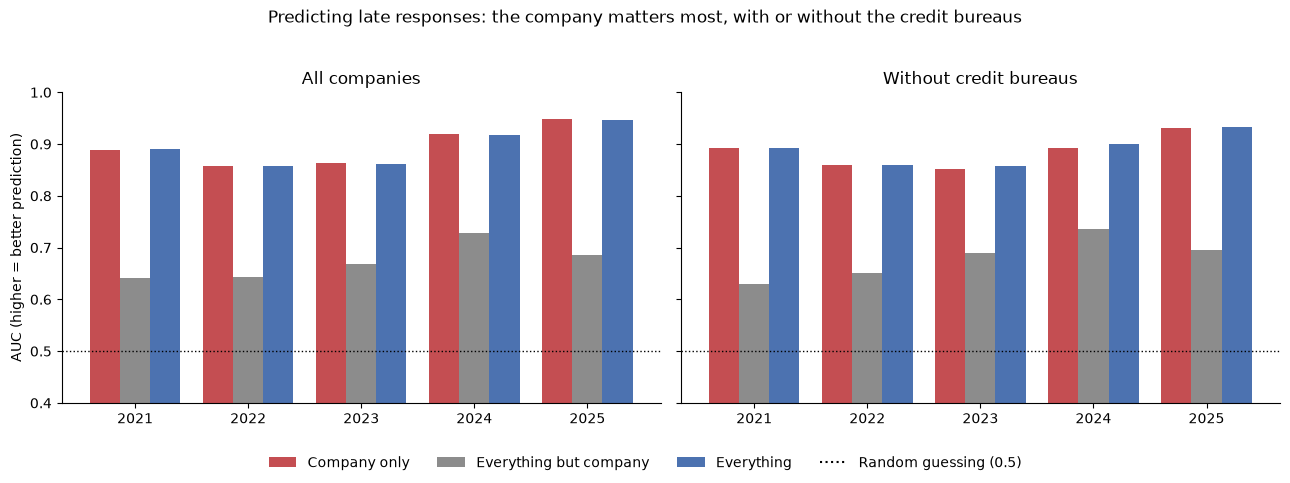

In [ ]:
import matplotlib.pyplot as plt

order = ["Company only", "Everything but company", "Everything"]
colors = ["#C44E52", "#8C8C8C", "#4C72B0"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for ax, (title, results) in zip(axes, [("All companies", model_results),
                                        ("Without credit bureaus", robust_results)]):
    auc = results.pivot(index="year", columns="features", values="AUC")[order]
    auc.plot(kind="bar", ax=ax, width=0.8, color=colors, legend=False)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylim(0.4, 1.0)
    ax.tick_params(axis="x", rotation=0)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("AUC (higher = better prediction)")

# One shared legend for both panels
handles, labels = axes[0].get_legend_handles_labels()
handles.append(plt.Line2D([], [], color="black", linestyle=":"))
labels.append("Random guessing (0.5)")
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

fig.suptitle("Predicting late responses: the company matters most, with or without the credit bureaus")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'late_episodes.png'

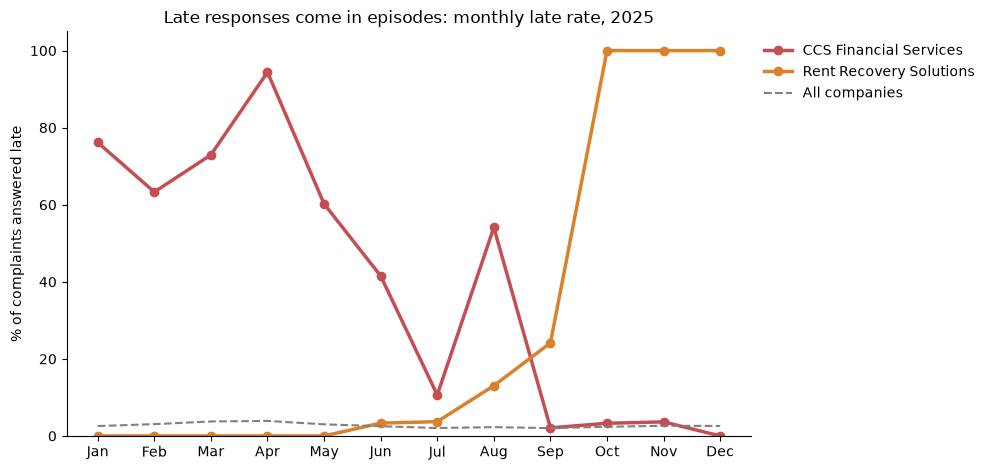

In [39]:
latest = df["year"].max()
d = df[df["year"] == latest].copy()
d["month"] = pd.to_datetime(d["Date received"]).dt.month

companies = {
    "CCS Financial Services, Inc.": "#C44E52",
    "Rent Recovery Solutions": "#D9822B",
}
monthly_all = d.groupby("month")["late"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4.8))
for company, color in companies.items():
    m = d[d["Company"] == company].groupby("month")["late"].mean() * 100
    ax.plot(m.index, m.values, marker="o", linewidth=2.5, color=color,
            label=company.replace(", Inc.", ""))
ax.plot(monthly_all.index, monthly_all.values, color="gray", linestyle="--",
        linewidth=1.5, label="All companies")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylim(0, 105)
ax.set_ylabel("% of complaints answered late")
ax.set_title(f"Late responses come in episodes: monthly late rate, {latest}")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("late_episodes.png", dpi=200, bbox_inches="tight")
plt.show()